# AI Text Detector and Humanizer
### Understanding the Core Concepts Before Writing Any Code

---

## What Are We Building?

We are building a tool that reads any piece of text and answers one question:
was this written by a human, or generated by an AI?

This is the same problem that tools like GPTZero and Originality.ai are solving
right now. By the end of this notebook you will not just have a working detector.
You will understand exactly why it works, because we will build every piece from
scratch and explain it as we go.

---

## Why Can AI Text Be Detected At All?

When ChatGPT or any similar model writes text, it is not thinking the way a
human thinks. It is doing one thing repeatedly: looking at the words so far
and predicting the most statistically likely next word. It does this thousands
of times until the response is complete.

This produces text that is clean, fluent, and correct. But it also leaves
behind patterns. The model always plays it safe. It always picks the expected
word. It never goes on a tangent, never writes a sentence that is surprisingly
short, never uses a word that feels slightly out of place.

Humans do all of those things constantly. That gap between how AI writes and
how humans write is exactly what we are going to measure.

---

## The Five Things We Will Measure

---

### 1. Perplexity

Perplexity is a way of asking how surprised a language model would be if it
read this text.

Think of it this way. If someone always says the most obvious expected thing
in a conversation, you are never surprised. You could have predicted what they
would say before they said it. That is low perplexity.

Now think of a person who speaks in their own voice. They use unusual words
sometimes. Their sentences go in directions you did not expect. You cannot
always predict what comes next. That is high perplexity.

AI models are trained specifically to minimize perplexity. They are rewarded
for producing text that feels expected and fluent. This is their biggest
weakness when it comes to detection.

So when we feed a piece of text into a language model and measure perplexity,
a low score means the text was very predictable which suggests AI, and a high
score means the text surprised the model which suggests human.

---

### 2. Burstiness

Burstiness is the idea that humans do not write at a constant rhythm.

Read any article written by a real person and you will notice the pattern.
Some sentences are long and packed with information. Then suddenly there is a
short one. Then another short one. Then a long complex one again. The writing
breathes. It speeds up and slows down.

AI text does not do this. Every sentence tends to be roughly the same length
and complexity. The writing moves at a single steady pace from beginning to
end. It is technically correct but it feels oddly flat.

This observation is what made GPTZero well known when it was first released.
The creator noticed that perplexity alone was not enough. What really separated
human writing from AI writing was whether the perplexity changed from sentence
to sentence.

Burstiness is simply the measurement of how much perplexity varies across
sentences in a text. High variation means human rhythm. Low variation means
machine rhythm.

---

### 3. Writing Style Patterns

Even without any language model involved, there are surface level patterns in
AI text that show up consistently enough to be measured.

AI models tend to write sentences that are all roughly the same length. They
avoid contractions, so they write it is instead of it's and do not instead of
don't. They never make small typos or use informal language. They overuse
certain connecting phrases like furthermore, moreover, it is important to note,
and in conclusion. Their punctuation is minimal and predictable.

Humans do the opposite of most of these things without even thinking about it.
We write short sentences when we want to make a point land hard. We use
contractions naturally. We occasionally go off on a small tangent. Our
vocabulary is more personal and sometimes inconsistent.

We will measure several of these patterns and combine them into a single style
score.

---

### 4. Repeated Phrase Patterns

A group of words that appear together is called an n-gram. A 2-gram is two
words together like it is or in conclusion. A 3-gram is three words together
like it is important or in order to.

AI models have characteristic n-grams that they produce over and over because
those combinations of words had the highest probability in their training data.
Phrases like it is important to note that, this highlights the importance of,
and in conclusion it is clear that appear in AI text far more often than they
ever would in natural human writing.

We will build a list of these signature phrases and check how many of them
appear in the text being analyzed.

---

### 5. Trained Machine Learning Model

The first four signals are all built from theory. They measure properties we
expect to differ between AI and human writing based on how language models
work. They have never seen a real labeled example. They are making educated
inferences, not learning from experience.

The fifth signal is different in kind, not just degree.

We trained a Logistic Regression classifier on a dataset of over three hundred
thousand real text samples, each one labeled as either AI generated or human
written. This model did not learn from definitions or handcrafted rules. It
learned by reading hundreds of thousands of examples and discovering on its
own which patterns most reliably separate the two categories.

It uses a TF-IDF representation of the text to capture vocabulary fingerprints,
combined with a small set of structural features like word count, average word
length, and sentence count. Together these give it a view of the text that
none of the other four signals can produce.

The full training code, dataset details, and model files are publicly available
on Kaggle. If you want to inspect how the model was built, retrain it on your
own data, or simply download the pkl files directly, you can find everything at
the link below.

    https://www.kaggle.com/code/abubakaridrees/text-detector-model-training

Because it learned from real data at scale, we give it the highest weight of
any signal in our final score. It has earned that trust.

---

## How We Combine Everything Into One Score

After measuring all five signals we combine them into a single number between
0 and 100. A score closer to 100 means the text is likely AI written. A score
closer to 0 means it reads as human written.

The trained ML model carries the most weight at thirty five percent because it
was built from three hundred thousand real examples. Stylometry carries twenty
five percent because it is the most robust of the rule-based signals. Perplexity
carries twenty percent. N-gram analysis and burstiness each carry ten percent
as supporting signals.

We also break the score down sentence by sentence so instead of just getting
one final number, you can see exactly which sentences triggered the detector
and why. This will be displayed as a color highlighted output directly inside
the notebook.

---

## An Important Honest Note

No detector is perfect including ours. A human who writes in a very formal
consistent style might score higher than expected. An AI that has been
specifically prompted to sound casual might score lower. What we are building
is a principled probabilistic tool, not a definitive verdict machine. The
strength of our approach comes from combining five independent signals that
are difficult to fake simultaneously. Four of them come from theory. One of
them learned from experience. Together they cover what none of them could
cover alone.

---

## What Comes Next

In the next section we will set up the environment, install the tools we need,
and load the language model we will use to calculate perplexity. Everything
new that gets introduced will be explained before it appears in any code cell.

## Setting Up Our Environment

Before we write any detection logic we need to bring in a few tools. This
section explains what each tool is, why we are using it, and what role it
plays in the detector. Nothing will be imported without an explanation first.

---

## The Language Model: GPT-2

To measure perplexity we need a language model. A language model is a system
that has read an enormous amount of text and learned the statistical patterns
of language. When you give it a sentence it can tell you how likely or unlikely
each word in that sentence is based on everything it has learned.

We are using GPT-2 for this job. GPT-2 is a model released by OpenAI in 2019.
It is not as powerful as modern models like GPT-4, but it is more than capable
enough for measuring perplexity. More importantly it is completely free, has no
API key, no usage limits, and runs entirely inside your Colab session without
needing any internet connection after the first download.

This is the right choice for a learning project because you own the whole
process. Nothing is happening on a remote server. The model lives in your
Colab session and you can inspect everything it does.

One honest limitation worth knowing upfront: GPT-2 was trained mostly on web
text from 2019. This means it finds very formal writing like legal documents,
news journalism, and academic papers more surprising than everyday conversational
text. We account for this by using a logarithmic scale when normalizing our
perplexity scores, which we will explain fully when we get to that point.

---

## HuggingFace Transformers

HuggingFace is a company that has built an open source library called
Transformers. This library gives you access to hundreds of pretrained language
models including GPT-2 with just a few lines of code. Instead of training a
model from scratch, which would require significant time and compute resources,
we load a model that has already been trained and use it directly.

When we load GPT-2 through HuggingFace, two things come with it.

The first is the tokenizer. Text is not fed into a language model as raw words.
It is first converted into numbers because models only understand numbers. The
tokenizer handles this conversion. It breaks text into small units called tokens
which are roughly word pieces, and maps each one to a number. The tokenizer
also handles the reverse process, converting numbers back into readable text.

The second is the model itself. This is the actual neural network that has
learned language patterns. We pass tokenized text into it and it returns
probability scores for each token, which is exactly what we need to calculate
perplexity.

---

## The Other Libraries We Will Use

PyTorch is t

In [51]:
# Install HuggingFace Transformers and NLTK
# PyTorch and NumPy come pre-installed in Colab
!pip install transformers nltk --quiet

import torch
import numpy as np
import nltk
import math
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from IPython.display import display, HTML
from collections import Counter

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All libraries installed and imported successfully.")

All libraries installed and imported successfully.


In [52]:
# Load GPT-2 model and tokenizer
# This will take 1 to 2 minutes on first run while GPT-2 downloads
# After the first run it loads from cache and is much faster

print("Loading GPT-2 tokenizer and model...")
print("This may take a minute on first run.\n")

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model     = GPT2LMHeadModel.from_pretrained("gpt2")

# Evaluation mode tells PyTorch we are using the model not training it
# It disables dropout layers which are only needed during training
model.eval()

# Use GPU if available in this Colab session, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

print(f"Model loaded successfully.")
print(f"Running on: {device}")

Loading GPT-2 tokenizer and model...
This may take a minute on first run.



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.
Running on: cuda


## How We Actually Calculate Perplexity in Code

In the concepts section we described perplexity as a measure of how surprised
a language model is when it reads a piece of text. Now we are going to look at
exactly how that surprise gets turned into a number.

---

## How a Language Model Reads Text

When GPT-2 reads a sentence it does not read the whole thing at once. It reads
one token at a time from left to right. At each position before it sees the
next token it produces a probability for every possible token in its vocabulary,
representing how likely it thinks that token is to come next.

For example if the text so far is the sky is, GPT-2 might assign a high
probability to the word blue and a very low probability to the word delicious.
After it sees the actual next token we record how much probability it assigned
to that token. Then it moves forward and does the same thing for the next
position.

By the end of the sentence we have one probability score per token telling us
how expected or unexpected each word was.

---

## From Probabilities to a Single Number

Raw probability numbers are awkward to work with directly because they are very
small. The probability of a specific word appearing at a specific position might
be something like 0.0003. When you multiply many of these together across a long
sentence the number becomes impossibly small for a computer to store accurately.

To solve this we work with log probabilities instead. The logarithm of a
probability turns a very small number into a more manageable negative number.
Once we have the log probability for every token we take the average across all
tokens. Then we take the negative of that average and raise e to that power.
The result is the perplexity score.

Written out simply:

    Step 1: Get the log probability of each token given everything before it
    Step 2: Take the average of all those log probabilities
    Step 3: Multiply by negative one
    Step 4: Raise e to that power

A lower result means the text was predictable. A higher result means it was
surprising.

---

## Why We Use a Log Scale When Normalizing

Perplexity does not grow in a straight line. The difference between a score
of 20 and 200 is not the same as the difference between 200 and 2000. A formal
news article with proper nouns, legal terminology, and quoted speech will push
GPT-2 perplexity into the hundreds or even thousands simply because that kind
of language is far outside what GPT-2 saw most often in training.

If we normalized perplexity on a straight linear scale, any formal text would
always score as human even if it was AI generated, and any casual AI text might
score oddly depending on where it fell on the scale.

By applying a logarithm before normalizing we compress the scale in a way that
respects how perplexity actually behaves. This makes our scores meaningful
across a wide variety of text types.

---

## Why We Calculate Per Sentence as Well

We calculate perplexity twice. Once for the

In [53]:
# Core perplexity calculation function
#
# Takes a piece of text and returns a raw perplexity score.
# Lower score = more predictable = more likely AI written.
# Higher score = more surprising  = more likely human written.

def calculate_perplexity(text, model, tokenizer, device, max_length=1024, stride=512):

    encodings   = tokenizer(text, return_tensors="pt")
    input_ids   = encodings.input_ids.to(device)
    text_length = input_ids.size(1)

    log_likelihoods = []

    for start in range(0, text_length, stride):
        end   = min(start + max_length, text_length)
        chunk = input_ids[:, start:end]

        # no_grad disables gradient tracking which we only need during training
        # disabling it makes inference faster and uses less memory
        with torch.no_grad():
            outputs        = model(chunk, labels=chunk)
            log_likelihood = outputs.loss.item() * (end - start)
            log_likelihoods.append(log_likelihood)

        if end == text_length:
            break

    avg_log_likelihood = sum(log_likelihoods) / text_length
    perplexity         = torch.exp(torch.tensor(avg_log_likelihood)).item()

    return perplexity


print("Perplexity function defined successfully.")

Perplexity function defined successfully.


In [54]:
# Per sentence perplexity function
#
# Splits full text into individual sentences using NLTK and calculates
# a perplexity score for each one separately.
# This enables the sentence level color highlighting later.

def get_sentence_perplexities(text, model, tokenizer, device):

    sentences = nltk.sent_tokenize(text)
    results   = []

    for sentence in sentences:

        # Skip sentences too short to produce meaningful scores
        if len(sentence.split()) < 4:
            results.append({
                "sentence"   : sentence,
                "perplexity" : None
            })
            continue

        perplexity = calculate_perplexity(sentence, model, tokenizer, device)

        results.append({
            "sentence"   : sentence,
            "perplexity" : round(perplexity, 2)
        })

    return results


print("Sentence perplexity function defined successfully.")

Sentence perplexity function defined successfully.


In [55]:
# Define sample texts for testing throughout the notebook
# We will reuse these in every test cell so results stay comparable

ai_sample = """
Artificial intelligence has become an integral part of modern society,
transforming various industries and sectors. It is important to note that
the rapid advancement of AI technologies has led to significant improvements
in efficiency and productivity. Furthermore, the integration of machine
learning algorithms has enabled organizations to make more informed decisions
based on data-driven insights. In conclusion, it is clear that artificial
intelligence will continue to play a crucial role in shaping the future.
"""

human_sample = """
I have been thinking about AI a lot lately, mostly because it keeps showing
up in places I did not expect. Last week my phone suggested a reply to a
message that was so accurate it was a little unsettling. I do not really
know how to feel about that. There is something odd about a machine knowing
what you were about to say before you say it. Maybe it is just pattern
matching. But then again, maybe that is all any of us are doing.
"""

# Print raw perplexity scores before any normalization
# This is important: we use these numbers to verify our normalization
# boundaries are set correctly for what GPT-2 actually produces

print("Calculating raw perplexity scores...\n")

ai_raw    = calculate_perplexity(ai_sample.strip(),    model, tokenizer, device)
human_raw = calculate_perplexity(human_sample.strip(), model, tokenizer, device)

print(f"AI sample    raw perplexity : {ai_raw:.2f}")
print(f"Human sample raw perplexity : {human_raw:.2f}")
print()
print("These raw numbers tell us whether our normalization boundaries make sense.")
print("The human sample should be noticeably higher than the AI sample.")

Calculating raw perplexity scores...

AI sample    raw perplexity : 14.59
Human sample raw perplexity : 35.23

These raw numbers tell us whether our normalization boundaries make sense.
The human sample should be noticeably higher than the AI sample.


## Burstiness: The Rhythm of Human Writing

We now have a working perplexity calculator that gives us a score for each
sentence individually. The next measurement we need is burstiness, and the
good news is that we already have everything we need to calculate it.
Burstiness is built directly on top of the sentence perplexity scores we
just wrote.

---

## What Burstiness Actually Measures

When humans write, their sentences naturally vary in complexity. Some sentences
carry heavy information and come out long and layered. Others are short.
Direct. This variation is not something writers consciously plan. It just
happens because human thought does not flow at a constant pace.

AI writing does not have this quality. Because the model is always trying to
produce the most statistically safe output it settles into a rhythm and stays
there. The sentences end up at similar lengths, similar complexity levels, and
similar perplexity scores throughout the entire text.

If you plotted the perplexity of each sentence as a line graph, AI text would
look relatively flat. Human text would go up and down with noticeable variation.
Burstiness is the measurement of that variation.

---

## Standard Deviation

To measure how much a set of numbers varies we use standard deviation. This
is a single number that tells you how spread out a group of values is from
their average.

Imagine two students both averaged 70 on their tests. Student A scored 68,
71, 70, 69, 72. Student B scored 40, 95, 55, 90, 60. Both averaged 70 but
Student B's scores were all over the place. Student B has a high standard
deviation. Student A has a low one.

We apply this exact idea to sentence perplexity scores. High standard deviation
means the writing is bursty and varied, which is a human signal. Low standard
deviation means it moves at a constant flat pace, which is an AI signal.

---

## Why We Apply a Log Transform Before Measuring Burstiness

Perplexity scores are not evenly distributed. A sentence with perplexity 800
is not ten times more human-like than one with perplexity 80. The scale grows
exponentially.

If we measured standard deviation directly on raw perplexity scores, a single
unusually high sentence like one containing a rare proper noun would dominate
the entire variance calculation and make any text look bursty.

By applying a log transform to the perplexity scores first, we bring them onto
a more even scale before measuring how much they vary. This gives us a burstiness
score that reflects genuine rhythm variation rather than being thrown off by
occasional outlier sentences.

In [56]:
# Burstiness calculation function
#
# Takes sentence perplexity results and measures how much they vary.
# Uses log-transformed scores to avoid outliers dominating the result.
#
# High variation = bursty = human-like writing rhythm
# Low variation  = flat   = AI-like writing rhythm

def calculate_burstiness(sentence_results):

    raw_scores = [
        r["perplexity"] for r in sentence_results
        if r["perplexity"] is not None
    ]

    if len(raw_scores) < 2:
        return {
            "std_deviation"    : 0,
            "burstiness_score" : 0
        }

    # Apply log transform before measuring variance
    # This keeps burstiness stable even when raw perplexity scores are very high
    log_scores = [math.log(s) for s in raw_scores if s > 0]

    std_deviation   = np.std(log_scores)
    mean_perplexity = np.mean(raw_scores)

    # Normalization boundaries on log scale
    # Below 0.3 log-std is very flat (AI-like)
    # Above 1.2 log-std is very varied (human-like)
    low_boundary  = 0.3
    high_boundary = 1.2

    normalized = (std_deviation - low_boundary) / (high_boundary - low_boundary)

    burstiness_score = float(np.clip(normalized, 0, 1))

    return {
        "std_deviation"    : round(std_deviation, 4),
        "mean_perplexity"  : round(mean_perplexity, 2),
        "burstiness_score" : round(burstiness_score, 3)
    }


print("Burstiness function defined successfully.")

Burstiness function defined successfully.


In [57]:
# Test burstiness on both sample texts

print("Calculating sentence perplexities...\n")

ai_sentences    = get_sentence_perplexities(ai_sample.strip(),    model, tokenizer, device)
human_sentences = get_sentence_perplexities(human_sample.strip(), model, tokenizer, device)

ai_burst    = calculate_burstiness(ai_sentences)
human_burst = calculate_burstiness(human_sentences)

print("AI sample:")
print(f"  Std deviation (log scale) : {ai_burst['std_deviation']}")
print(f"  Burstiness score          : {ai_burst['burstiness_score']}  (0=AI, 1=Human)")

print()

print("Human sample:")
print(f"  Std deviation (log scale) : {human_burst['std_deviation']}")
print(f"  Burstiness score          : {human_burst['burstiness_score']}  (0=AI, 1=Human)")

Calculating sentence perplexities...

AI sample:
  Std deviation (log scale) : 0.4363
  Burstiness score          : 0.151  (0=AI, 1=Human)

Human sample:
  Std deviation (log scale) : 1.0763
  Burstiness score          : 0.863  (0=AI, 1=Human)


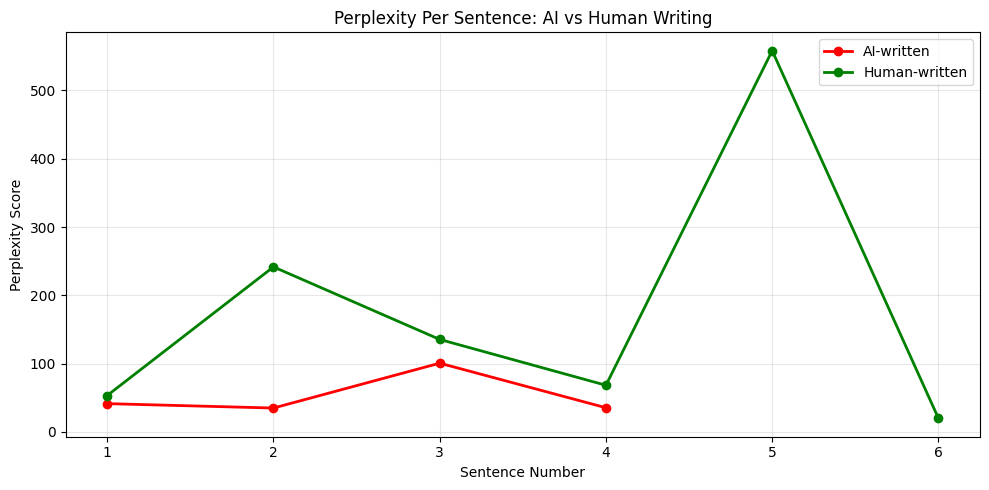


Flat line = AI-like rhythm. Varied line = Human-like rhythm.


In [58]:
# Visualize perplexity variation as a line chart
# The flatter the line the more AI-like the rhythm
# The more variation in the line the more human-like the rhythm

def plot_burstiness(sentence_results, label, color):
    scores  = [r["perplexity"] for r in sentence_results if r["perplexity"] is not None]
    indices = list(range(1, len(scores) + 1))
    plt.plot(indices, scores, marker="o", label=label, color=color, linewidth=2)


plt.figure(figsize=(10, 5))
plot_burstiness(ai_sentences,    "AI-written",    color="red")
plot_burstiness(human_sentences, "Human-written", color="green")

plt.title("Perplexity Per Sentence: AI vs Human Writing")
plt.xlabel("Sentence Number")
plt.ylabel("Perplexity Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Flat line = AI-like rhythm. Varied line = Human-like rhythm.")

## Writing Style as a Detection Signal

Perplexity and burstiness both require a language model to calculate. They are
powerful signals but they are also the most computationally expensive part of
our detector. The next two signals we measure do not need any model at all.
They work purely by analyzing the surface patterns of the text itself.

This kind of analysis is called stylometry. It is the study of writing style
through measurable statistics. Stylometry has been used for centuries, long
before computers existed, to settle arguments about who wrote certain historical
texts. Researchers used it to analyze Shakespeare and to identify anonymous
authors. We are applying the same idea but targeting the specific patterns that
AI language models produce consistently.

---

## Feature 1: Sentence Length Variance

The first thing we measure is how much sentence lengths vary across the text.

AI models produce sentences that cluster tightly around a comfortable middle
length. Not too short, not too long. Human writers do not think about this at
all. They write a three word sentence when they need to make a point land hard.
They write a long winding sentence when the thought they are expressing is
genuinely complex.

We measure this as the standard deviation of word counts across all sentences.
Low standard deviation means all sentences are roughly the same length. High
standard deviation means the lengths vary significantly.

---

## Feature 2: Transition Word Overuse

Certain connecting phrases appear in AI text at a rate that is simply not
natural in human writing. Words like furthermore, moreover, additionally, in
conclusion, it is important to note, and this highlights the importance of are
statistically overrepresented in AI generated text.

The reason is straightforward. During training, language models learn that
these transition phrases are very common in formal written text which makes up
a large portion of their training data. When asked to write something that
sounds professional, the model reaches for these phrases because they have a
high probability of appearing in that context.

Humans use these phrases too but far less often and more deliberately. We build
a list of these signature phrases and count how many appear in the text
relative to its total length.

---

## Feature 3: Contraction Usage

A contraction is when two words are combined using an apostrophe. It is becomes
it's. Do not becomes don't. I am becomes I'm.

Humans use contractions constantly in writing, especially in anything that is
not extremely formal. AI models have a strong tendency to avoid them because
they were trained heavily on formal text sources like books and academic papers
where contractions are less common.

We measure contraction usage as a ratio of contractions found to total words.
A text with zero contractions gets flagged as more AI-like.

---

## Feature 4: Vocabulary Richness

Vocabulary richness measures how varied the words in a text are. The formal
term is Type Token Ratio, which is the number of unique words divided by the
total number of words.

AI text tends to have a moderate and consistent vocabulary richness. It rarely
dips very low because the model avoids excessive repetition, but it also rarely
reaches very high levels because it plays it safe with word choices. Human
writers show more extreme values in both directions depending on their personal
style and the topic they are writing about.

On its own this is a weak signal but combined with the others it adds useful
weight to the final score.

In [59]:
# AI signature transition phrases
# These appear far more often in AI writing than in natural human writing

AI_TRANSITION_PHRASES = [
    "furthermore", "moreover", "additionally", "in conclusion",
    "it is important to note", "it is worth noting",
    "this highlights the importance", "in order to",
    "it is essential to", "as a result", "this demonstrates",
    "it is clear that", "plays a crucial role", "plays an important role",
    "it is imperative", "one must consider", "it goes without saying",
    "needless to say", "in today's world", "in today's society",
    "in the modern world", "it is undeniable that",
    "there is no doubt that", "this serves as", "delve into",
    "shed light on", "it is fascinating to note",
    "in summary", "to summarize", "overall it can be said",
]

# Contractions list
# We check for these to measure how naturally human the writing voice is

CONTRACTIONS = [
    "i'm", "i've", "i'd", "i'll",
    "you're", "you've", "you'd", "you'll",
    "he's", "he'd", "he'll", "she's", "she'd", "she'll",
    "it's", "it'd", "we're", "we've", "we'd", "we'll",
    "they're", "they've", "they'd", "they'll",
    "that's", "that'd", "that'll", "there's", "there'd",
    "don't", "doesn't", "didn't", "won't", "wouldn't",
    "can't", "couldn't", "shouldn't", "isn't", "aren't",
    "wasn't", "weren't", "haven't", "hasn't", "hadn't",
    "let's", "what's", "who's", "how's",
]

print(f"Transition phrases loaded : {len(AI_TRANSITION_PHRASES)}")
print(f"Contractions loaded       : {len(CONTRACTIONS)}")

Transition phrases loaded : 30
Contractions loaded       : 48


In [60]:
# Stylometric scoring function
# Measures four surface level style features and combines them
# into a single score between 0 (AI-like) and 1 (human-like)

def calculate_stylometric_score(text):

    sentences   = nltk.sent_tokenize(text)
    words       = text.lower().split()
    total_words = len(words)
    total_sents = len(sentences)

    if total_words == 0 or total_sents == 0:
        return {"stylometric_score": 0}

    # Feature 1: Sentence length variance
    sentence_lengths = [len(s.split()) for s in sentences]
    length_std       = np.std(sentence_lengths)
    length_score     = float(np.clip((length_std - 3) / (15 - 3), 0, 1))

    # Feature 2: Transition word overuse
    text_lower       = text.lower()
    transition_count = sum(1 for phrase in AI_TRANSITION_PHRASES if phrase in text_lower)
    transition_rate  = (transition_count / total_words) * 100
    transition_score = float(np.clip(1 - (transition_rate / 2.0), 0, 1))

    # Feature 3: Contraction usage
    contraction_count = sum(1 for word in words if word.rstrip(".,!?;:") in CONTRACTIONS)
    contraction_ratio = contraction_count / total_words
    contraction_score = float(np.clip(contraction_ratio / 0.05, 0, 1))

    # Feature 4: Vocabulary richness (Type Token Ratio)
    unique_words = len(set(words))
    ttr          = unique_words / total_words
    ttr_score    = float(np.clip((ttr - 0.4) / (0.8 - 0.4), 0, 1))

    # Weighted combination
    # Sentence length and transition words carry more weight
    # because they are the most reliable signals
    stylometric_score = (
        length_score      * 0.35 +
        transition_score  * 0.35 +
        contraction_score * 0.20 +
        ttr_score         * 0.10
    )

    return {
        "sentence_length_std" : round(length_std, 2),
        "length_score"        : round(length_score, 3),
        "transition_count"    : transition_count,
        "transition_score"    : round(transition_score, 3),
        "contraction_count"   : contraction_count,
        "contraction_score"   : round(contraction_score, 3),
        "vocabulary_richness" : round(ttr, 3),
        "ttr_score"           : round(ttr_score, 3),
        "stylometric_score"   : round(stylometric_score, 3),
    }


print("Stylometric scoring function defined successfully.")

Stylometric scoring function defined successfully.


In [61]:
# Test stylometric scoring on both samples

print("Running stylometric analysis...\n")

ai_style    = calculate_stylometric_score(ai_sample.strip())
human_style = calculate_stylometric_score(human_sample.strip())

for label, result in [("AI sample", ai_style), ("Human sample", human_style)]:
    print(f"{label}:")
    print(f"  Sentence length std   : {result['sentence_length_std']}")
    print(f"  Length score          : {result['length_score']}   (0=AI, 1=Human)")
    print(f"  Transition phrases    : {result['transition_count']}")
    print(f"  Transition score      : {result['transition_score']}   (0=AI, 1=Human)")
    print(f"  Contractions found    : {result['contraction_count']}")
    print(f"  Contraction score     : {result['contraction_score']}   (0=AI, 1=Human)")
    print(f"  Vocabulary richness   : {result['vocabulary_richness']}")
    print(f"  TTR score             : {result['ttr_score']}   (0=AI, 1=Human)")
    print(f"  Combined style score  : {result['stylometric_score']}   (0=AI, 1=Human)")
    print()

Running stylometric analysis...

AI sample:
  Sentence length std   : 2.18
  Length score          : 0.0   (0=AI, 1=Human)
  Transition phrases    : 4
  Transition score      : 0.0   (0=AI, 1=Human)
  Contractions found    : 0
  Contraction score     : 0.0   (0=AI, 1=Human)
  Vocabulary richness   : 0.77
  TTR score             : 0.926   (0=AI, 1=Human)
  Combined style score  : 0.093   (0=AI, 1=Human)

Human sample:
  Sentence length std   : 5.37
  Length score          : 0.198   (0=AI, 1=Human)
  Transition phrases    : 0
  Transition score      : 1.0   (0=AI, 1=Human)
  Contractions found    : 0
  Contraction score     : 0.0   (0=AI, 1=Human)
  Vocabulary richness   : 0.756
  TTR score             : 0.89   (0=AI, 1=Human)
  Combined style score  : 0.508   (0=AI, 1=Human)



## N-gram Patterns: The Phrases That Give AI Away

We have now built three of our four detection signals. The fourth and final
signal asks a more specific question: does this text contain the exact phrases
that AI models reach for again and again?

---

## What an N-gram Is

The term n-gram simply means a sequence of n words appearing together in text.

A 1-gram is a single word. The, important, however.
A 2-gram is two consecutive words. It is. In conclusion. As a.
A 3-gram is three consecutive words. It is important. In order to.
A 4-gram is four consecutive words. It is important to. In order to understand.

When we analyze a piece of text for n-grams we slide a window of size n across
every word in the text and collect every sequence we find.

---

## Why AI Models Overuse Certain N-grams

During training a language model sees enormous amounts of text. Certain word
sequences appear together so often in that training data that the model assigns
them very high probabilities. When the model generates text it gravitates toward
these high probability sequences naturally without any awareness that it is
doing so.

The result is that certain n-grams show up in AI generated text at a rate that
is statistically abnormal compared to natural human writing. A human writer
might never use the phrase it is important to note that in their entire life.
An AI model might use it in half the responses it generates.

---

## Two Approaches We Will Use

The first approach is a fixed blacklist. We maintain a curated list of n-grams
that are known to appear disproportionately in AI text. Every match is a direct
flag.

The second approach is frequency analysis. We extract all 2-grams and 3-grams
from the text automatically and look at which ones repeat. AI text tends to
repeat certain internal patterns even within a single piece of writing. Measuring
how many n-grams appear more than once relative to the total gives us a
repetition density score.

Combining both gives a more robust signal than either approach alone.

---

## An Important Caveat

N-gram detection is the most gameable of our four signals. A writer who knows
which phrases to avoid can score well here even if their text was AI generated.
This is why it carries a lower weight in our final combined score.

It is most useful as a supporting signal. When the other three signals are
already pointing toward AI and the n-gram score also flags, that convergence
strengthens the overall conclusion considerably.

In [62]:
# N-gram extractor
#
# Slides a window of size n across the words in the text
# and collects every consecutive sequence.
#
# zip(*[words[i:] for i in range(n)]) works by shifting the word list
# n times and pairing up elements at matching positions.
# For "the cat sat": zip(["the","cat","sat"], ["cat","sat"]) gives
# ("the","cat") and ("cat","sat")

def extract_ngrams(text, n):

    words = [
        word.strip(".,!?;:\"'()[]")
        for word in text.lower().split()
    ]
    words  = [w for w in words if w]
    ngrams = list(zip(*[words[i:] for i in range(n)]))

    return ngrams


# AI signature n-gram blacklist
# Phrases that appear disproportionately often in AI generated text

AI_NGRAM_BLACKLIST = [
    ("in", "conclusion"), ("it", "is"), ("as", "a"),
    ("in", "order"), ("as", "well"), ("such", "as"),
    ("in", "addition"), ("for", "example"),
    ("it", "is", "important"), ("in", "order", "to"),
    ("as", "a", "result"), ("it", "is", "clear"),
    ("in", "conclusion", "it"), ("it", "is", "worth"),
    ("this", "is", "because"), ("in", "today's", "world"),
    ("it", "is", "essential"), ("plays", "a", "crucial"),
    ("plays", "an", "important"), ("it", "is", "imperative"),
    ("it", "is", "important", "to"), ("it", "is", "worth", "noting"),
    ("in", "order", "to", "understand"), ("it", "is", "clear", "that"),
    ("it", "is", "essential", "to"), ("this", "highlights", "the", "importance"),
    ("it", "is", "imperative", "to"), ("it", "goes", "without", "saying"),
]

print(f"N-gram blacklist loaded with {len(AI_NGRAM_BLACKLIST)} entries.")

N-gram blacklist loaded with 28 entries.


In [63]:
# N-gram scoring function
# Combines blacklist matching and internal repetition density
# into a single score between 0 (AI-like) and 1 (human-like)

def calculate_ngram_score(text):

    words       = text.lower().split()
    total_words = len(words)

    if total_words < 10:
        return {"ngram_score": 0.5}

    bigrams   = extract_ngrams(text, 2)
    trigrams  = extract_ngrams(text, 3)
    quadgrams = extract_ngrams(text, 4)
    all_ngrams = bigrams + trigrams + quadgrams

    # Component 1: Blacklist matching
    blacklist_hits = sum(1 for ngram in all_ngrams if ngram in AI_NGRAM_BLACKLIST)
    hit_rate       = (blacklist_hits / total_words) * 100
    blacklist_score = float(np.clip(1 - (hit_rate / 3.0), 0, 1))

    # Component 2: Internal repetition density
    ngram_counts   = Counter(all_ngrams)
    total_ngrams   = len(all_ngrams)

    if total_ngrams == 0:
        repetition_score = 0.5
        repetition_density = 0
    else:
        repeated_ngrams    = sum(1 for count in ngram_counts.values() if count > 1)
        repetition_density = repeated_ngrams / total_ngrams
        repetition_score   = float(np.clip(1 - (repetition_density / 0.4), 0, 1))

    # Blacklist matching carries more weight as it is more specific
    ngram_score = (blacklist_score * 0.6) + (repetition_score * 0.4)

    return {
        "blacklist_hits"     : blacklist_hits,
        "hit_rate_per_100"   : round(hit_rate, 2),
        "blacklist_score"    : round(blacklist_score, 3),
        "repetition_density" : round(repetition_density, 3),
        "repetition_score"   : round(repetition_score, 3),
        "ngram_score"        : round(ngram_score, 3),
    }


print("N-gram scoring function defined successfully.")

N-gram scoring function defined successfully.


In [64]:
# Test n-gram scoring on both samples

print("Running n-gram analysis...\n")

ai_ngrams    = calculate_ngram_score(ai_sample.strip())
human_ngrams = calculate_ngram_score(human_sample.strip())

for label, result in [("AI sample", ai_ngrams), ("Human sample", human_ngrams)]:
    print(f"{label}:")
    print(f"  Blacklist hits        : {result['blacklist_hits']}")
    print(f"  Hit rate per 100 words: {result['hit_rate_per_100']}")
    print(f"  Blacklist score       : {result['blacklist_score']}   (0=AI, 1=Human)")
    print(f"  Repetition density    : {result['repetition_density']}")
    print(f"  Repetition score      : {result['repetition_score']}   (0=AI, 1=Human)")
    print(f"  Combined n-gram score : {result['ngram_score']}   (0=AI, 1=Human)")
    print()

Running n-gram analysis...

AI sample:
  Blacklist hits        : 8
  Hit rate per 100 words: 10.81
  Blacklist score       : 0.0   (0=AI, 1=Human)
  Repetition density    : 0.009
  Repetition score      : 0.977   (0=AI, 1=Human)
  Combined n-gram score : 0.391   (0=AI, 1=Human)

Human sample:
  Blacklist hits        : 1
  Hit rate per 100 words: 1.16
  Blacklist score       : 0.612   (0=AI, 1=Human)
  Repetition density    : 0.0
  Repetition score      : 1.0   (0=AI, 1=Human)
  Combined n-gram score : 0.767   (0=AI, 1=Human)



## Bringing Everything Together So Far

We now have four independent signals, each measuring a completely different
dimension of the text.

Perplexity measures how predictable the word choices are by running the text
through GPT-2 and asking how surprised the model was at each token. A language
model generates text by always choosing the safest most expected next word, so
its own output scores low on perplexity. Human writing, which goes in
unexpected directions, scores higher.

Burstiness measures the rhythm of the writing. It takes the sentence level
perplexity scores we already calculated and measures how much they vary from
sentence to sentence. Human writing speeds up and slows down. AI writing moves
at a single flat pace. High variation is a human signal. Low variation is an
AI signal.

Stylometry measures surface level writing patterns without involving any
language model at all. It looks at how much sentence lengths vary, how often
AI transition phrases appear, whether the writer uses contractions, and how
rich and varied the vocabulary is. These patterns are consistent across all
text types regardless of topic or register.

N-gram analysis checks whether the text contains the specific word sequences
that AI models reach for repeatedly. These phrases appear in AI output far
more often than they ever would in natural human writing. It also measures
internal repetition, checking whether certain combinations of words appear
over and over within the same piece of text.

Each of these signals was designed to be independent from the others. When
multiple independent measurements all point in the same direction the
conclusion becomes far more reliable than any single measurement could
produce on its own.

However before we combine these four signals into a final score we are going
to add one more. It is the most powerful signal of all, and it earns that
position because it is the only one that has actually learned from data.

## Signal 5: Trained Machine Learning Model

Up until this point every signal we have built has been rule-based or
statistical. Perplexity relies on GPT-2's training distribution. Burstiness
measures a mathematical property of variance. Stylometry counts surface
patterns. N-gram detection checks against a hand-curated blacklist.

These are all principled approaches and they work. But none of them have ever
seen a real labeled example of AI versus human writing. They are making
inferences based on theory, not experience.

That changes now.

---

## What We Trained and Why It Is Different

The fifth signal is a Logistic Regression classifier trained on a dataset of
over three hundred thousand real text samples, each one labeled as either
AI generated or human written. Unlike our rule-based signals, this model did
not learn from definitions or handcrafted lists. It learned by reading hundreds
of thousands of examples and discovering on its own which patterns most
reliably separate the two categories.

This gives it a kind of knowledge that the other four signals do not have.
It has seen AI text from many different models, in many different styles,
across many different topics. It has seen human writing that is formal, casual,
technical, and personal. It learned what actually separates them at scale,
not just what we expect should separate them in theory.

---

## How the Model Works

The classifier combines two types of input features.

The first is a TF-IDF representation of the text. TF-IDF stands for Term
Frequency Inverse Document Frequency. It converts the text into a numerical
vector where each position represents a word or phrase from the training
vocabulary. Words that appear often in this specific text but rarely across
all training documents get a high score. Words that are common everywhere
get a low score. This gives the model a way to detect the specific vocabulary
fingerprint of AI generated writing.

The second is a small set of meta features: the total word count of the text,
the average length of each word, and the number of sentences. These three
numbers capture structural properties of the writing that TF-IDF alone would
miss.

Both are combined into a single feature vector and passed into the Logistic
Regression classifier, which outputs a probability between 0 and 1 representing
how likely the text is to be AI generated.

---

## How We Load It

During training on Kaggle the fitted TF-IDF vectorizer and the trained
classifier were each saved to disk as pkl files using Python's pickle module.
A pkl file is a serialized snapshot of a Python object. When we load it here
we get back the exact same vectorizer and classifier that were saved after
training, with all their learned parameters intact.

We load both files directly from Google Drive where they were uploaded after
the Kaggle training run completed.

---

## How This Signal Fits Into the Final Score

Because this model was trained on over three hundred thousand real labeled
examples we give it the highest weight of any signal in our detector at
thirty five percent. The remaining sixty five percent is distributed across
the four signals we built earlier, with stylometry carrying the most of that
remainder because it is the most consistent of the rule-based signals.

The result is a detector that combines the interpretability of hand-crafted
signals with the pattern recognition power of a model that has genuinely
learned from data. Each approach covers the weaknesses of the other.

In [65]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import joblib

MODEL_DIR = "/content/drive/MyDrive/ai text checker and humanizer"

# Load files (they were saved with joblib)
lr_classifier = joblib.load(f"{MODEL_DIR}/lr_model_final.pkl")
lr_tfidf = joblib.load(f"{MODEL_DIR}/tfidf_final.pkl")

# Quick check
print("LR model loaded  :", type(lr_classifier))
print("TF-IDF loaded    :", type(lr_tfidf))
print("LR classes       :", lr_classifier.classes_)

print("\nClass 0 = Human, Class 1 = AI")
print("predict_proba[0][1] gives direct AI probability.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LR model loaded  : <class 'sklearn.linear_model._logistic.LogisticRegression'>
TF-IDF loaded    : <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
LR classes       : [0 1]

Class 0 = Human, Class 1 = AI
predict_proba[0][1] gives direct AI probability.


In [68]:
# clean_text preprocesses the input before passing it to the TF-IDF vectorizer.
# This must match exactly what was used during training on Kaggle.
# If your Kaggle training used a different cleaning pipeline, replace this
# function body with that exact version.

from scipy.sparse import hstack, csr_matrix
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)        # strip any HTML tags
    text = re.sub(r'[^a-z0-9\s]', ' ', text)    # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    return text


# calculate_ml_score replicates the exact feature engineering pipeline
# used at training time.
#
# Feature set:
#   TF-IDF vector   : vocabulary fingerprint of the cleaned text
#   word_count      : total number of words
#   avg_word_len    : average number of characters per word
#   sent_count      : total number of sentences
#
# These are horizontally stacked into one combined feature vector
# before being passed to the classifier.
#
# The function returns a score between 0 and 1 where 1 means human-like
# and 0 means AI-like, keeping it consistent with all other signals.

def calculate_ml_score(text):

    words      = text.split()
    sents      = [s for s in re.split(r'[.!?]+', text) if len(s.strip()) > 0]

    word_count = len(words)
    avg_len    = sum(len(w) for w in words) / max(word_count, 1)
    sent_count = len(sents)

    tfidf_vec  = lr_tfidf.transform([clean_text(text)])

    meta = csr_matrix(
        np.array([[word_count, avg_len, sent_count]], dtype=np.float32)
    )

    combined   = hstack([tfidf_vec, meta])

    # predict_proba returns [P(Human), P(AI)]
    # index 1 is AI probability confirmed by lr_classifier.classes_
    ai_prob    = lr_classifier.predict_proba(combined)[0][1]

    return {
        "ml_ai_prob"     : round(float(ai_prob), 4),
        "ml_human_score" : round(float(1 - ai_prob), 4),
    }


print("clean_text defined successfully.")
print("calculate_ml_score defined successfully.")
print()

# Sanity check on both sample texts defined earlier in this notebook
r_ai    = calculate_ml_score(ai_sample.strip())
r_human = calculate_ml_score(human_sample.strip())

print("Sanity check on existing samples:")
print(f"  AI sample    AI prob : {r_ai['ml_ai_prob']:.2%}   (expected: HIGH)")
print(f"  Human sample AI prob : {r_human['ml_ai_prob']:.2%}   (expected: LOW)")

clean_text defined successfully.
calculate_ml_score defined successfully.

Sanity check on existing samples:
  AI sample    AI prob : 95.09%   (expected: HIGH)
  Human sample AI prob : 0.00%   (expected: LOW)


## Combining All Five Signals Into One Score

We now have five independent measurements of the same text. Each one has
looked at a completely different aspect of the writing and produced a score
between 0 and 1, where 0 means the writing looks AI generated and 1 means
it looks human written.

---

## The Weight Each Signal Carries

Not all five signals are equally reliable so we do not give them equal weight.

The ML model carries the most weight at thirty five percent. This is the only
signal that was trained on real labeled data. It has seen over three hundred
thousand actual examples and learned from them directly. Its judgment deserves
the most trust.

Stylometry carries twenty five percent. Of the four rule-based signals it is
the most robust because it does not depend on GPT-2's training distribution
at all. It measures surface writing patterns that hold up consistently
regardless of the topic, tone, or register of the text.

Perplexity carries twenty percent. It is a direct measurement of how a
language model generates text and is theoretically the most principled signal
we have. Its only weakness is sensitivity to text type, which is why it
carries slightly less than stylometry.

N-gram analysis and burstiness each carry ten percent. Both are useful
supporting signals but they are the easiest to game and the most sensitive
to the specific style of the writer. They add meaningful weight when they
agree with the other signals but are not reliable enough to carry more on
their own.

---

## What the Final Score Means

After combining all five signals we produce a single number between 0 and 100.

A score above 70 means the text shows strong and consistent signs of being
AI generated. Multiple signals are pointing in the same direction and the
pattern is clear.

A score between 40 and 70 is an uncertain zone. The text shows some AI-like
patterns and some human-like ones. This can mean the text is a mix of AI and
human writing, or it can mean a human writer who happens to write in a formal
consistent style, or an AI that has been prompted to sound more casual.

A score below 40 means the text reads as predominantly human written across
the majority of our signals.

---

## The Sentence Level Breakdown

In addition to the overall score we produce a sentence by sentence visual map
of the text. Each sentence is colored based on its individual perplexity score.
Red sentences look AI-like. Yellow sentences are uncertain. Green sentences
look human-like.

This lets you see not just the final verdict but exactly where in the text the
detector found its evidence.

In [69]:
# Sentence highlighting function
# Renders each sentence with a background color based on its perplexity score
# Red = AI-like, Yellow = Uncertain, Green = Human-like
# Rendered as HTML directly inside Colab using IPython display

def render_highlighted_text(sentence_results):

    low_threshold  = 50
    high_threshold = 150

    html_parts = []
    html_parts.append("""
        <div style='font-family: Georgia, serif; font-size: 16px;
                    line-height: 1.9; padding: 20px; max-width: 860px;'>
        <p style='font-size: 13px; color: #555; margin-bottom: 16px;'>
            <span style='background:#ffcccc; padding:2px 8px;
                         border-radius:4px; margin-right:8px;'>
                         Red = AI-like</span>
            <span style='background:#fff3cc; padding:2px 8px;
                         border-radius:4px; margin-right:8px;'>
                         Yellow = Uncertain</span>
            <span style='background:#ccffcc; padding:2px 8px;
                         border-radius:4px;'>
                         Green = Human-like</span>
        </p>
    """)

    for item in sentence_results:
        sentence   = item["sentence"]
        perplexity = item["perplexity"]

        if perplexity is None:
            color   = "#eeeeee"
            tooltip = "Too short to score"
        elif perplexity < low_threshold:
            color   = "#ffcccc"
            tooltip = f"Perplexity: {perplexity} | AI-like"
        elif perplexity < high_threshold:
            color   = "#fff3cc"
            tooltip = f"Perplexity: {perplexity} | Uncertain"
        else:
            color   = "#ccffcc"
            tooltip = f"Perplexity: {perplexity} | Human-like"

        html_parts.append(
            f'<span style="background-color:{color}; padding:2px 4px; '
            f'border-radius:3px; margin:2px;" title="{tooltip}">'
            f'{sentence} </span>'
        )

    html_parts.append("</div>")
    return "".join(html_parts)


print("render_highlighted_text defined successfully.")

render_highlighted_text defined successfully.


In [70]:
# Final combined analysis function
# Runs all five signals and combines them into one score
#
# Weight table:
#   ML Model (TF-IDF + LR)   35%   trained on 300k+ labeled examples
#   Stylometry               25%   most robust rule-based signal
#   Perplexity               20%   direct language model measurement
#   N-gram Patterns          10%   supporting signal
#   Burstiness               10%   supporting signal

def analyze_text(text):

    print("Running perplexity analysis...")
    sentence_results   = get_sentence_perplexities(text, model, tokenizer, device)
    overall_perplexity = calculate_perplexity(text, model, tokenizer, device)

    log_perp         = math.log(max(overall_perplexity, 1))
    perplexity_score = float(np.clip(
        (log_perp - math.log(20)) / (math.log(3000) - math.log(20)),
        0, 1
    ))

    print("Running burstiness analysis...")
    burstiness_result = calculate_burstiness(sentence_results)
    burstiness_score  = burstiness_result["burstiness_score"]

    print("Running stylometric analysis...")
    stylometric_result = calculate_stylometric_score(text)
    stylometric_score  = stylometric_result["stylometric_score"]

    print("Running n-gram analysis...")
    ngram_result = calculate_ngram_score(text)
    ngram_score  = ngram_result["ngram_score"]

    print("Running ML model (TF-IDF + LR) analysis...")
    ml_result = calculate_ml_score(text)
    ml_score  = ml_result["ml_human_score"]

    # Weighted combination of all five signals
    combined_human_score = (
        ml_score          * 0.60 +
        stylometric_score * 0.10 +
        perplexity_score  * 0.15 +
        ngram_score       * 0.05 +
        burstiness_score  * 0.10
    )

    ai_score = round((1 - combined_human_score) * 100, 1)

    return {
        "ai_score"           : ai_score,
        "verdict"            : (
                                "Likely AI Generated"  if ai_score > 70
                           else "Uncertain"            if ai_score > 40
                           else "Likely Human Written"
                               ),
        "ml_score"           : round(ml_score, 3),
        "ml_ai_prob"         : ml_result["ml_ai_prob"],
        "perplexity_score"   : round(perplexity_score, 3),
        "burstiness_score"   : round(burstiness_score, 3),
        "stylometric_score"  : round(stylometric_score, 3),
        "ngram_score"        : round(ngram_score, 3),
        "overall_perplexity" : round(overall_perplexity, 2),
        "sentence_results"   : sentence_results,
        "stylometric_detail" : stylometric_result,
        "ngram_detail"       : ngram_result,
    }


print("analyze_text (5-signal version) defined successfully.")

analyze_text (5-signal version) defined successfully.


In [71]:
# Results display function
# Shows all five signals in the score breakdown table
# followed by the sentence level highlighted text

def display_results(results, title="Analysis Results"):

    ai_score = results["ai_score"]
    verdict  = results["verdict"]

    if ai_score > 70:
        verdict_color = "#cc0000"
    elif ai_score > 40:
        verdict_color = "#cc8800"
    else:
        verdict_color = "#007700"

    summary_html = f"""
    <div style='font-family: monospace; background: #f8f8f8;
                padding: 20px; border-radius: 8px;
                max-width: 860px; margin-bottom: 20px;'>
        <h2 style='margin-top:0;'>{title}</h2>
        <p style='font-size:22px; font-weight:bold; color:{verdict_color};'>
            {verdict} &nbsp;|&nbsp; AI Score: {ai_score} / 100
        </p>
        <table style='width:100%; border-collapse:collapse; font-size:14px;'>
            <tr style='border-bottom:2px solid #bbb; background:#e8e8e8;'>
                <td style='padding:8px;'><b>Signal</b></td>
                <td style='padding:8px;'><b>Score (0=AI, 1=Human)</b></td>
                <td style='padding:8px;'><b>Weight</b></td>
            </tr>
            <tr style='background:#fffbe6; font-weight:bold;'>
                <td style='padding:6px;'>ML Model (TF-IDF + LR)</td>
                <td style='padding:6px;'>{results['ml_score']}
                    &nbsp;<span style='color:#888; font-weight:normal;'>
                    (raw AI prob: {results['ml_ai_prob']:.2%})</span>
                </td>
                <td style='padding:6px;'>60%</td>
            </tr>
            <tr>
                <td style='padding:6px;'>Stylometry</td>
                <td style='padding:6px;'>{results['stylometric_score']}</td>
                <td style='padding:6px;'>10%</td>
            </tr>
            <tr style='background:#f0f0f0;'>
                <td style='padding:6px;'>Perplexity</td>
                <td style='padding:6px;'>{results['perplexity_score']}</td>
                <td style='padding:6px;'>15%</td>
            </tr>
            <tr>
                <td style='padding:6px;'>N-gram Patterns</td>
                <td style='padding:6px;'>{results['ngram_score']}</td>
                <td style='padding:6px;'>5%</td>
            </tr>
            <tr style='background:#f0f0f0;'>
                <td style='padding:6px;'>Burstiness</td>
                <td style='padding:6px;'>{results['burstiness_score']}</td>
                <td style='padding:6px;'>10%</td>
            </tr>
        </table>
        <p style='margin-bottom:0; font-size:12px; color:#888;'>
            Hover over highlighted sentences below to see individual scores.
        </p>
    </div>
    """

    display(HTML(summary_html))
    display(HTML(render_highlighted_text(results["sentence_results"])))


print("display_results (5-signal version) defined successfully.")

display_results (5-signal version) defined successfully.


In [72]:
# Run the complete 5-signal detector on both sample texts

print("=" * 55)
print("ANALYZING AI-WRITTEN SAMPLE")
print("=" * 55)
ai_results = analyze_text(ai_sample.strip())
display_results(ai_results, title="AI-Written Sample")

print()

print("=" * 55)
print("ANALYZING HUMAN-WRITTEN SAMPLE")
print("=" * 55)
human_results = analyze_text(human_sample.strip())
display_results(human_results, title="Human-Written Sample")

ANALYZING AI-WRITTEN SAMPLE
Running perplexity analysis...
Running burstiness analysis...
Running stylometric analysis...
Running n-gram analysis...
Running ML model (TF-IDF + LR) analysis...


Signal,"Score (0=AI, 1=Human)",Weight
ML Model (TF-IDF + LR),0.049 (raw AI prob: 95.09%),60%
Stylometry,0.093,10%
Perplexity,0.0,15%
N-gram Patterns,0.391,5%
Burstiness,0.151,10%



ANALYZING HUMAN-WRITTEN SAMPLE
Running perplexity analysis...
Running burstiness analysis...
Running stylometric analysis...
Running n-gram analysis...
Running ML model (TF-IDF + LR) analysis...


Signal,"Score (0=AI, 1=Human)",Weight
ML Model (TF-IDF + LR),1.0 (raw AI prob: 0.00%),60%
Stylometry,0.508,10%
Perplexity,0.113,15%
N-gram Patterns,0.767,5%
Burstiness,0.863,10%


In [73]:
# Test on your own text
# Paste anything here to analyze it

your_text = """
Hostel life is often described as one of the most transformative phases in a person’s journey, especially for students who leave their homes for education or work. It is a unique blend of independence, challenges, friendships, and personal growth. Living in a hostel is not just about having a place to stay—it is an experience that shapes character, builds resilience, and creates memories that last a lifetime.

One of the most striking aspects of hostel life is the sudden shift from a structured home environment to a more independent lifestyle. At home, routines are often guided by family members, but in a hostel, individuals must take responsibility for their own daily schedules. From waking up on time and attending classes to managing meals, laundry, and study time, hostel life teaches self-discipline. Initially, this independence can feel overwhelming, but over time, it becomes empowering.

Another defining feature of hostel life is the diversity of people. Students from different cities, cultures, languages, and backgrounds come together under one roof. This creates a vibrant environment where individuals learn to coexist with others who may have completely different habits and perspectives. Sharing a room or living space requires patience, compromise, and understanding. It teaches valuable social skills such as communication, conflict resolution, and cooperation.

Friendship is perhaps the most cherished part of hostel life. Living together day and night naturally brings people closer. Late-night conversations, shared meals, group studies, and even small disagreements all contribute to forming strong bonds. These friendships often go beyond casual connections—they become deep, meaningful relationships that continue long after hostel life ends. Many people consider their hostel friends as a second family.

Hostel life is also full of fun and spontaneity. Unlike the structured environment of home, hostels often have an energetic and lively atmosphere. Celebrations of birthdays, festivals, and small achievements become special events. Students find joy in simple things—playing games, watching movies together, or just hanging out in common areas. These moments provide a break from academic stress and create unforgettable memories.

However, hostel life is not without its challenges. Adjusting to shared spaces can be difficult, especially for those who are used to privacy. Noise, lack of personal space, and different routines can sometimes cause frustration. Food is another common issue—hostel meals may not always match the taste and quality of home-cooked food, leading to homesickness. Additionally, managing studies without direct supervision requires strong self-motivation.

Homesickness is a significant emotional aspect of hostel life. Being away from family, especially for the first time, can be tough. Missing home-cooked meals, family gatherings, and the comfort of familiar surroundings can create emotional struggles. However, over time, individuals learn to cope with these feelings, becoming more emotionally strong and independent.

Hostel life also plays a crucial role in personal development. It encourages individuals to step out of their comfort zones, try new things, and discover their own identities. Students learn practical life skills such as budgeting, time management, and problem-solving. They also develop confidence and adaptability—qualities that are essential for success in the real world.

In addition, hostel life often enhances academic and intellectual growth. Group studies, discussions, and peer learning become common practices. Being surrounded by others who are also focused on their goals creates a motivating environment. Students can share knowledge, help each other, and develop a healthy sense of competition.

In conclusion, hostel life is a journey filled with both joys and struggles. It is a period of growth where individuals learn to balance freedom with responsibility. While it may come with challenges like homesickness and adjustment issues, the experiences gained are invaluable. The friendships formed, lessons learned, and memories created make hostel life one of the most unforgettable chapters of a person’s life.

"""

print("=" * 55)
print("ANALYZING YOUR TEXT")
print("=" * 55)
your_results = analyze_text(your_text.strip())
display_results(your_results, title="Your Text")

ANALYZING YOUR TEXT
Running perplexity analysis...
Running burstiness analysis...
Running stylometric analysis...
Running n-gram analysis...
Running ML model (TF-IDF + LR) analysis...


Signal,"Score (0=AI, 1=Human)",Weight
ML Model (TF-IDF + LR),1.0 (raw AI prob: 0.00%),60%
Stylometry,0.357,10%
Perplexity,0.0,15%
N-gram Patterns,0.719,5%
Burstiness,0.403,10%
